# Lambda × subtract_wt_baseline × n_voxels decoding sweep

All variants: model 31, smoothed, `--fit_responses`.

**Current availability (2026-03-09):**

| condition | n_voxels | lambda | n subs |
|-----------|----------|--------|--------|
| subtract=off | 0, 100, 200 | 0.0 | 39 |
| subtract=off | 0, 200 | 0.1 – 0.8 | 39 |
| subtract=off | 0 | 0.9 | 34 |
| subtract=off | 200 | 0.9 – 1.0 | 39 |
| subtract=off | 0 | 1.0 | 7 (incomplete) |
| subtract=on | 200 | 0.0 – 1.0 | 39 |

**Three analyses:**

- **Part A** – voxel-count effect at lambda=0: n_voxels = 0 / 100 / 200
- **Part B** – lambda sweep: n_voxels=0 (lambda 0–0.9) vs 200 (lambda 0–1.0)
- **Part C** – subtract_wt_baseline effect: n_voxels=200, lambda 0–1.0

Primary metric: Pearson r (decoded posterior mean E vs. behavioural response x).

In [31]:
import numpy as np
import pandas as pd
from pathlib import Path
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from neural_priors.utils.data import get_all_subject_ids

bids_folder = Path('/data/ds-neuralpriors')
subjects = get_all_subject_ids()
print(f'{len(subjects)} subjects')

39 subjects


In [32]:
# ── helpers ───────────────────────────────────────────────────────────────────

def build_key(model_label=31, smoothed=True, spherical_noise=False,
              fit_responses=False, separate_sigmas=False,
              subtract_wt_baseline=False, lambd=0.0):
    key = f'model{model_label}'
    if smoothed:             key += '.smoothed'
    if spherical_noise:      key += '.spherical_noise'
    if fit_responses:        key += '.fit_responses'
    if separate_sigmas:      key += '.separate_sigmas'
    if subtract_wt_baseline: key += '.subtract_wt_baseline'
    if lambd > 0.0:          key += f'.lambd-{lambd}'
    return key


def load_pdf(subject, key, n_voxels, roi='NPCr'):
    fn = (bids_folder / 'derivatives' / 'decoding2' / key
          / f'sub-{subject}' / 'func'
          / f'sub-{subject}_mask-{roi}_nvoxels-{n_voxels}_pars.tsv')
    pdf = pd.read_csv(fn, sep='\t', index_col=[0, 1, 2, 3, 4], header=[0, 1])
    pdf.columns.names = ['n', 'range']
    pdf.columns = pd.MultiIndex.from_arrays(
        [pdf.columns.get_level_values(0).astype(np.float32),
         pdf.columns.get_level_values(1)],
        names=pdf.columns.names)
    return pdf.sort_index(level=['session', 'run', 'trial_nr'])


def posterior_mean(pdf_slice):
    vals = pdf_slice.values
    x = pdf_slice.columns.astype(float).values
    norms = np.trapz(vals, x, axis=1)
    vals_n = vals / norms[:, None]
    E = np.trapz(vals_n * x[None, :], x, axis=1)
    mad = np.trapz(np.abs(E[:, None] - x[None, :]) * vals_n, x, axis=1)
    return E, mad


def summarize_pdf(pdf):
    E_n, mad_n = posterior_mean(pdf.xs('0.0', level='range', axis=1))
    E_w, mad_w = posterior_mean(pdf.xs('1.0', level='range', axis=1))
    range_idx = pdf.index.get_level_values('range')
    E   = np.where(range_idx == 0.0, E_n, E_w)
    mad = np.where(range_idx == 0.0, mad_n, mad_w)
    df = pdf.index.to_frame(index=False)[['session', 'run', 'trial_nr', 'x', 'range']]
    df['E']         = E
    df['mad']       = mad
    df['error']     = E - df['x']
    df['abs_error'] = np.abs(df['error'])
    df['range']     = df['range'].map({0.0: 'narrow', 1.0: 'wide'})
    return df


def subject_metrics(subject, key, n_voxels):
    try:
        pdf  = load_pdf(subject, key, n_voxels)
        pars = summarize_pdf(pdf)
    except FileNotFoundError:
        return None
    rows = []
    for rng, g in pars.groupby('range'):
        r   = pg.corr(g['E'], g['x'], method='pearson')['r'].values[0]
        mae = g['abs_error'].mean()
        rows.append({'range': rng, 'r': r, 'mae': mae})
    return pd.DataFrame(rows).assign(subject=subject)


def collect_metrics(key, n_voxels):
    results = [m for sub in subjects
               if (m := subject_metrics(sub, key, n_voxels)) is not None]
    return pd.concat(results, ignore_index=True) if results else None

## Load data

In [33]:
# nv=200 is complete for all lambda; nv=0 complete through 0.8, partial at 0.9, tiny at 1.0
lambda_nv200    = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
lambda_nv0      = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]  # skip 1.0 (n=7)

# ── Part A: voxel-count at lambda=0, subtract=off ────────────────────────────
voxel_dfs = []
for nv in tqdm([0, 100, 200], desc='Part A n_voxels'):
    key = build_key(fit_responses=True)
    df  = collect_metrics(key, nv)
    if df is not None:
        df['n_voxels'] = nv
        voxel_dfs.append(df)

voxel_data = pd.concat(voxel_dfs, ignore_index=True)

# ── Part B: lambda sweep, nv=0 vs nv=200, subtract=off ──────────────────────
sweep_dfs = []
for nv, lambdas in [(0, lambda_nv0), (200, lambda_nv200)]:
    for lam in tqdm(lambdas, desc=f'Part B nv={nv}'):
        key = build_key(fit_responses=True, lambd=lam)
        df  = collect_metrics(key, nv)
        if df is not None:
            df['n_voxels'] = nv
            df['lambda']   = lam
            sweep_dfs.append(df)

sweep_data = pd.concat(sweep_dfs, ignore_index=True)

# ── Part C: subtract sweep, nv=200, all lambda ───────────────────────────────
sub_dfs = []
for subtract in tqdm([False, True], desc='Part C subtract'):
    for lam in lambda_nv200:
        key = build_key(fit_responses=True, subtract_wt_baseline=subtract, lambd=lam)
        df  = collect_metrics(key, 200)
        if df is not None:
            df['subtract_wt_baseline'] = subtract
            df['lambda'] = lam
            sub_dfs.append(df)

sub_data = pd.concat(sub_dfs, ignore_index=True)
sub_data['subtract_label'] = sub_data['subtract_wt_baseline'].map(
    {False: 'raw W', True: 'baseline-subtracted W'})

print('Part A n per group:')
print(voxel_data.groupby(['n_voxels', 'range'])['subject'].nunique())
print('\nPart B n per (nv, lambda):')
print(sweep_data.groupby(['n_voxels', 'lambda'])['subject'].nunique().unstack('n_voxels'))
print('\nPart C n per (subtract, lambda):')
print(sub_data.groupby(['subtract_wt_baseline', 'lambda'])['subject'].nunique().unstack('lambda'))

Part A n_voxels:   0%|          | 0/3 [00:00<?, ?it/s]

Part B nv=0:   0%|          | 0/10 [00:00<?, ?it/s]

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_78453/1323076212.py:33: RuntimeWarning: invalid value encountered in divide
  vals_n = vals / norms[:, None]
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_78453/1323076212.py:33: RuntimeWarning: invalid value encountered in divide
  vals_n = vals / norms[:, None]
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_78453/1323076212.py:33: RuntimeWarning: invalid value encountered in divide
  vals_n = vals / norms[:, None]
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_78453/1323076212.py:33: RuntimeWarning: invalid value encountered in divide
  vals_n = vals / norms[:, None]
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_78453/1323076212.py:33: RuntimeWarning: invalid value encountered in divide
  vals_n = vals / norms[:, None]
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_78453/1323076212.py:33: RuntimeWarning: invalid value encountered in divide
  vals_n = vals / norms[:

Part B nv=200:   0%|          | 0/11 [00:00<?, ?it/s]

Part C subtract:   0%|          | 0/2 [00:00<?, ?it/s]

Part A n per group:
n_voxels  range 
0         narrow    39
          wide      39
100       narrow    39
          wide      39
200       narrow    39
          wide      39
Name: subject, dtype: int64

Part B n per (nv, lambda):
n_voxels   0     200
lambda              
0.0       39.0  39.0
0.1       39.0  39.0
0.2       39.0  39.0
0.3       39.0  39.0
0.4       39.0  39.0
0.5       39.0  39.0
0.6       39.0  39.0
0.7       39.0  39.0
0.8       39.0  39.0
0.9       34.0  39.0
1.0        NaN  39.0

Part C n per (subtract, lambda):
lambda                0.0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.0
subtract_wt_baseline                                                       
False                  39   39   39   39   39   39   39   39   39   39   39
True                   39   39   39   39   39   39   39   39   39   39   39


## Part A: Voxel-count effect (lambda=0, subtract=off)

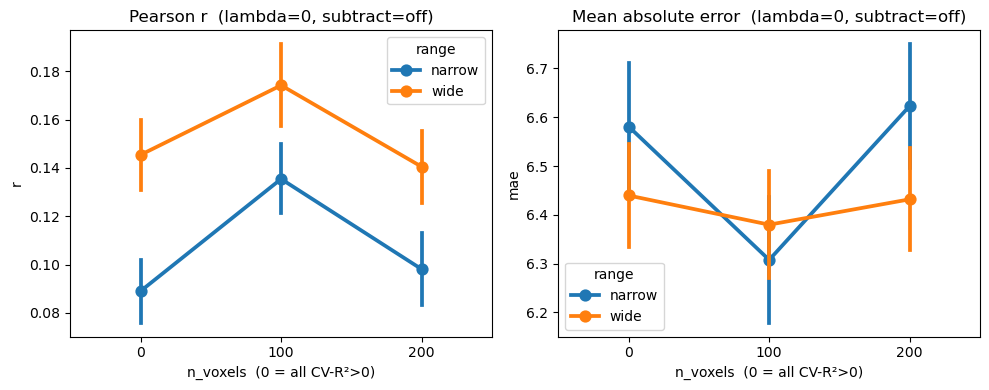

Paired t-tests (r averaged over range):
  n=0 vs n=100: Δr=+0.0376, T=-3.89, p=0.0004
  n=100 vs n=200: Δr=-0.0355, T=3.92, p=0.0004
  n=0 vs n=200: Δr=+0.0021, T=-0.26, p=0.7960


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, metric, title in zip(axes, ['r', 'mae'], ['Pearson r', 'Mean absolute error']):
    sns.pointplot(data=voxel_data, x='n_voxels', y=metric, hue='range',
                  order=[0, 100, 200], errorbar='se', ax=ax)
    ax.set_title(f'{title}  (lambda=0, subtract=off)')
    ax.set_xlabel('n_voxels  (0 = all CV-R²>0)')

plt.tight_layout()
plt.savefig('voxel_count_effect.png', dpi=150)
plt.show()

# Paired t-tests: 100 vs 200, and 0 vs 200
print('Paired t-tests (r averaged over range):')
avg_r = voxel_data.groupby(['subject', 'n_voxels'])['r'].mean()
for a, b in [(0, 100), (100, 200), (0, 200)]:
    ra, rb = avg_r.xs(a, level='n_voxels'), avg_r.xs(b, level='n_voxels')
    common = ra.index.intersection(rb.index)
    t = pg.ttest(ra[common], rb[common], paired=True)
    print(f'  n={a} vs n={b}: Δr={rb[common].mean()-ra[common].mean():+.4f}, '
          f'T={t["T"].values[0]:.2f}, p={t["p-val"].values[0]:.4f}')

## Part B: Lambda sweep — n_voxels=0 vs 200 (subtract=off)

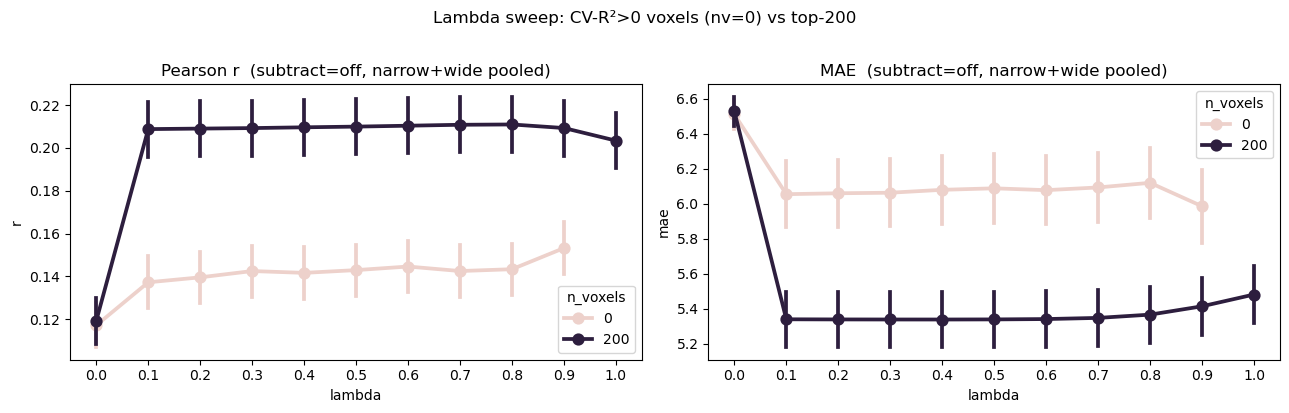

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)


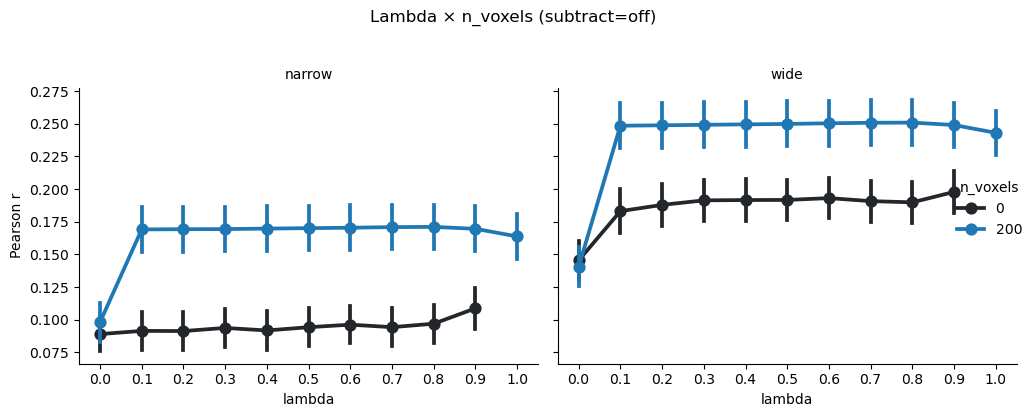

Paired t-tests nv=0 vs nv=200 (r averaged over range):
  lam=0.0: nv=0 r=0.117, nv=200 r=0.119, Δ=-0.002, p=0.7960
  lam=0.1: nv=0 r=0.137, nv=200 r=0.209, Δ=-0.072, p=0.0006*
  lam=0.2: nv=0 r=0.140, nv=200 r=0.209, Δ=-0.069, p=0.0006*
  lam=0.3: nv=0 r=0.143, nv=200 r=0.209, Δ=-0.067, p=0.0006*
  lam=0.4: nv=0 r=0.142, nv=200 r=0.210, Δ=-0.068, p=0.0006*
  lam=0.5: nv=0 r=0.143, nv=200 r=0.210, Δ=-0.067, p=0.0006*
  lam=0.6: nv=0 r=0.145, nv=200 r=0.210, Δ=-0.066, p=0.0006*
  lam=0.7: nv=0 r=0.143, nv=200 r=0.211, Δ=-0.068, p=0.0006*
  lam=0.8: nv=0 r=0.143, nv=200 r=0.211, Δ=-0.068, p=0.0005*
  lam=0.9: nv=0 r=0.153, nv=200 r=0.199, Δ=-0.046, p=0.0117*


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric, title in zip(axes, ['r', 'mae'], ['Pearson r', 'MAE']):
    sns.pointplot(data=sweep_data, x='lambda', y=metric,
                  hue='n_voxels', errorbar='se', dodge=False, ax=ax)
    ax.set_title(f'{title}  (subtract=off, narrow+wide pooled)')
    ax.set_xlabel('lambda')
    ax.legend(title='n_voxels')

plt.suptitle('Lambda sweep: CV-R²>0 voxels (nv=0) vs top-200', y=1.02)
plt.tight_layout()
plt.savefig('lambda_sweep_nv0_vs_nv200.png', dpi=150)
plt.show()

# Also split by range
g = sns.FacetGrid(sweep_data, col='range', height=4, aspect=1.2)
g.map_dataframe(sns.pointplot, x='lambda', y='r',
                hue='n_voxels', errorbar='se', dodge=False)
g.add_legend(title='n_voxels')
g.set_axis_labels('lambda', 'Pearson r')
g.set_titles('{col_name}')
plt.suptitle('Lambda × n_voxels (subtract=off)', y=1.03)
plt.tight_layout()
plt.show()

# Paired t-test: nv=0 vs nv=200 at each shared lambda (averaged over range)
shared_lambdas = sorted(set(lambda_nv0) & set(lambda_nv200))
print('Paired t-tests nv=0 vs nv=200 (r averaged over range):')
for lam in shared_lambdas:
    r0   = sweep_data[(sweep_data['n_voxels']==0)   & (sweep_data['lambda']==lam)].groupby('subject')['r'].mean()
    r200 = sweep_data[(sweep_data['n_voxels']==200) & (sweep_data['lambda']==lam)].groupby('subject')['r'].mean()
    common = r0.index.intersection(r200.index)
    t = pg.ttest(r0[common], r200[common], paired=True)
    sig = '*' if t['p-val'].values[0] < 0.05 else ''
    print(f'  lam={lam}: nv=0 r={r0[common].mean():.3f}, nv=200 r={r200[common].mean():.3f}, '
          f'Δ={r0[common].mean()-r200[common].mean():+.3f}, p={t["p-val"].values[0]:.4f}{sig}')

## Part C: subtract_wt_baseline × lambda (n_voxels=200)

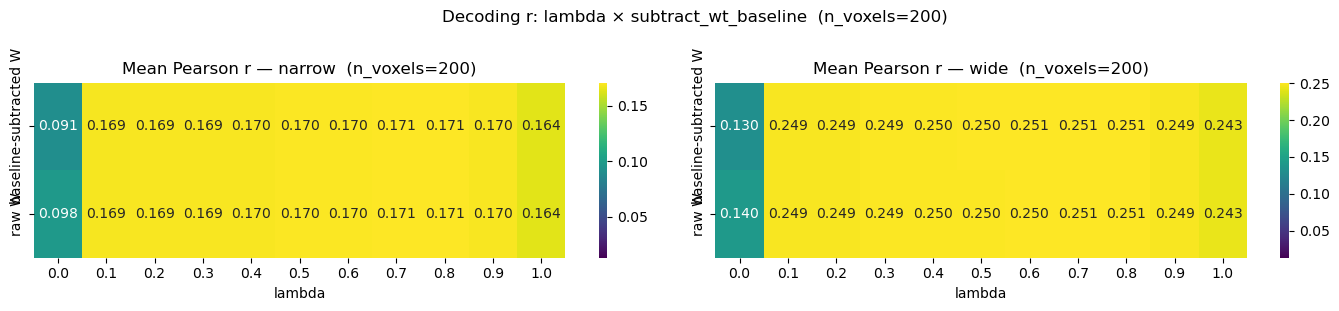

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3))

for ax, rng in zip(axes, ['narrow', 'wide']):
    pivot = (sub_data[sub_data['range'] == rng]
             .groupby(['subtract_label', 'lambda'])['r']
             .mean()
             .unstack('lambda'))
    vmin = sub_data['r'].quantile(0.05)
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis', ax=ax, vmin=vmin)
    ax.set_title(f'Mean Pearson r — {rng}  (n_voxels=200)')
    ax.set_xlabel('lambda')
    ax.set_ylabel('')

plt.suptitle('Decoding r: lambda × subtract_wt_baseline  (n_voxels=200)', y=1.02)
plt.tight_layout()
plt.savefig('lambda_heatmap_n200.png', dpi=150, bbox_inches='tight')
plt.show()

### Best lambda per subject

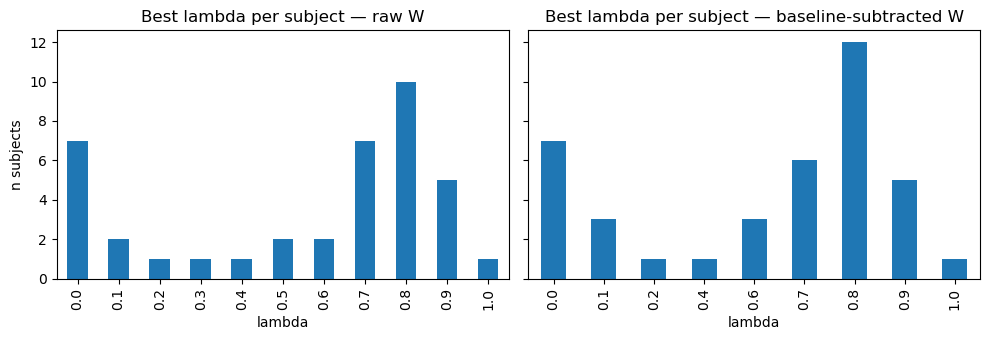

Group-level mean r by lambda × subtract:
lambda                   0.0     0.1     0.2     0.3     0.4   0.5     0.6  \
subtract_wt_baseline                                                         
False                 0.1193  0.2088  0.2091  0.2093  0.2097  0.21  0.2104   
True                  0.1105  0.2089  0.2091  0.2093  0.2097  0.21  0.2105   

lambda                   0.7    0.8     0.9     1.0  
subtract_wt_baseline                                 
False                 0.2108  0.211  0.2093  0.2034  
True                  0.2108  0.211  0.2093  0.2034  
  Best lambda (raw): 0.8
  Best lambda (subtract): 0.8


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)

for ax, (subtract, grp) in zip(axes, sub_data.groupby('subtract_wt_baseline')):
    label = 'baseline-subtracted W' if subtract else 'raw W'
    best = (grp.groupby(['subject', 'lambda'])['r']
               .mean().reset_index()
               .sort_values('r', ascending=False)
               .groupby('subject').first()['lambda'])
    best.value_counts().sort_index().plot(kind='bar', ax=ax)
    ax.set_title(f'Best lambda per subject — {label}')
    ax.set_xlabel('lambda')
    ax.set_ylabel('n subjects')

plt.tight_layout()
plt.show()

print('Group-level mean r by lambda × subtract:')
best_lam = (sub_data.groupby(['subtract_wt_baseline', 'lambda'])['r']
            .mean().unstack('lambda').round(4))
print(best_lam)
for subtract, row in best_lam.iterrows():
    label = 'subtract' if subtract else 'raw'
    print(f'  Best lambda ({label}): {row.idxmax()}')

### Paired test: does subtract_wt_baseline help?

In [38]:
rows = []
for lam in lambda_nv200:
    for rng in ['narrow', 'wide']:
        sub = sub_data[(sub_data['lambda'] == lam) & (sub_data['range'] == rng)]
        raw  = sub[~sub['subtract_wt_baseline']].set_index('subject')['r']
        subt = sub[sub['subtract_wt_baseline']].set_index('subject')['r']
        common = raw.index.intersection(subt.index)
        if len(common) < 3:
            continue
        t = pg.ttest(raw[common], subt[common], paired=True)
        rows.append({
            'lambda': lam, 'range': rng,
            'r_raw': raw[common].mean(),
            'r_subtract': subt[common].mean(),
            'delta_r': subt[common].mean() - raw[common].mean(),
            'T': t['T'].values[0],
            'p': t['p-val'].values[0],
        })

tests = pd.DataFrame(rows)
tests['sig'] = tests['p'] < 0.05
display(tests.round(4))

,lambda,range,r_raw,r_subtract,delta_r,T,p,sig
0,0.0,narrow,0.0981,0.0907,-0.0073,0.7591,0.4525,False
1,0.0,wide,0.1405,0.1304,-0.0101,1.4292,0.1611,False
2,0.1,narrow,0.1691,0.1692,0.0001,-0.2256,0.8227,False
3,0.1,wide,0.2485,0.2487,0.0002,-0.8568,0.3969,False
4,0.2,narrow,0.1693,0.1693,0.0000,-0.1613,0.8727,False
5,0.2,wide,0.2488,0.2489,0.0000,-0.2128,0.8326,False
6,0.3,narrow,0.1694,0.1694,0.0000,-0.0886,0.9298,False
7,0.3,wide,0.2492,0.2492,0.0000,-0.1535,0.8788,False
8,0.4,narrow,0.1698,0.1698,0.0000,-0.1245,0.9016,False
9,0.4,wide,0.2496,0.2496,0.0001,-0.4234,0.6744,False


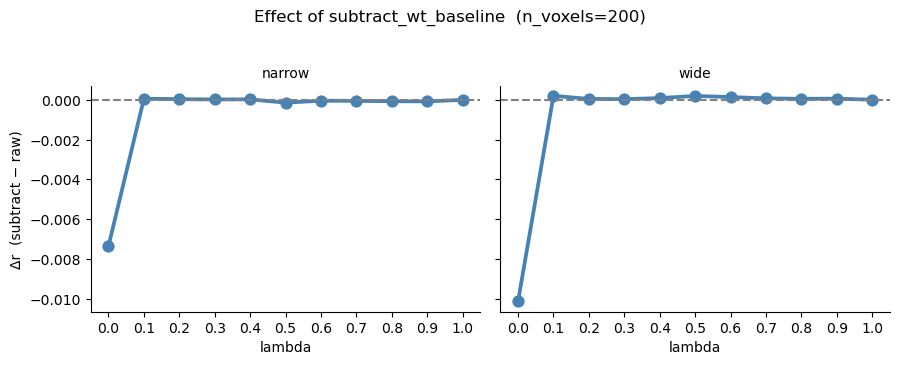

In [39]:
g = sns.FacetGrid(tests, col='range', height=3.5, aspect=1.3)
g.map_dataframe(sns.pointplot, x='lambda', y='delta_r', color='steelblue')
g.set_axis_labels('lambda', 'Δr  (subtract − raw)')
g.set_titles('{col_name}')
for ax in g.axes.flat:
    ax.axhline(0, color='grey', linestyle='--')
plt.suptitle('Effect of subtract_wt_baseline  (n_voxels=200)', y=1.03)
plt.tight_layout()
plt.show()

## Summary table

In [40]:
print('=== Part A: voxel-count effect (lambda=0, subtract=off) ===')
display(voxel_data.groupby(['n_voxels', 'range'])
        .agg(n=('subject','nunique'), mean_r=('r','mean'), sem_r=('r','sem'),
             mean_mae=('mae','mean'), sem_mae=('mae','sem'))
        .round(4))

print('\n=== Part B: lambda sweep (subtract=off) ===')
display(sweep_data.groupby(['n_voxels', 'lambda', 'range'])
        .agg(n=('subject','nunique'), mean_r=('r','mean'), sem_r=('r','sem'))
        .round(4))

print('\n=== Part C: subtract × lambda (n_voxels=200) ===')
display(sub_data.groupby(['subtract_label', 'lambda', 'range'])
        .agg(n=('subject','nunique'), mean_r=('r','mean'), sem_r=('r','sem'),
             mean_mae=('mae','mean'), sem_mae=('mae','sem'))
        .round(4))

=== Part A: voxel-count effect (lambda=0, subtract=off) ===


n  mean_r   sem_r  mean_mae  sem_mae
n_voxels range                                        
0        narrow  39  0.0890  0.0131    6.5810   0.1296
         wide    39  0.1454  0.0145    6.4396   0.1057
100      narrow  39  0.1354  0.0143    6.3076   0.1286
         wide    39  0.1742  0.0170    6.3798   0.1090
200      narrow  39  0.0981  0.0148    6.6232   0.1264
         wide    39  0.1405  0.0148    6.4318   0.1049


=== Part B: lambda sweep (subtract=off) ===


n  mean_r   sem_r
n_voxels lambda range                     
0        0.0    narrow  39  0.0890  0.0131
                wide    39  0.1454  0.0145
         0.1    narrow  39  0.0915  0.0146
                wide    39  0.1831  0.0167
         0.2    narrow  39  0.0913  0.0145
                wide    39  0.1879  0.0158
         0.3    narrow  39  0.0937  0.0145
                wide    39  0.1914  0.0155
         0.4    narrow  39  0.0918  0.0147
                wide    39  0.1916  0.0158
         0.5    narrow  39  0.0943  0.0144
                wide    39  0.1917  0.0156
         0.6    narrow  39  0.0962  0.0141
                wide    39  0.1931  0.0153
         0.7    narrow  39  0.0943  0.0145
                wide    39  0.1908  0.0157
         0.8    narrow  39  0.0969  0.0144
                wide    39  0.1899  0.0157
         0.9    narrow  34  0.1087  0.0156
                wide    34  0.1979  0.0159
200      0.0    narrow  39  0.0981  0.0148
                wide    39  0.1405  0.0148
         0.1    narrow  39  0.1691  0.0171
                wide    39  0.2485  0.0172
         0.2    narrow  39  0.1693  0.0171
                wide    39  0.2488  0.0172
         0.3    narrow  39  0.1694  0.0171
                wide    39  0.2492  0.0172
         0.4    narrow  39  0.1698  0.0171
                wide    39  0.2496  0.0172
         0.5    narrow  39  0.1701  0.0171
                wide    39  0.2499  0.0172
         0.6    narrow  39  0.1704  0.0171
                wide    39  0.2504  0.0172
         0.7    narrow  39  0.1709  0.0171
                wide    39  0.2508  0.0172
         0.8    narrow  39  0.1711  0.0171
                wide    39  0.2509  0.0172
         0.9    narrow  39  0.1696  0.0171
                wide    39  0.2490  0.0171
         1.0    narrow  39  0.1638  0.0170
                wide    39  0.2431  0.0169


=== Part C: subtract × lambda (n_voxels=200) ===


n  mean_r   sem_r  mean_mae  sem_mae
subtract_label        lambda range                                        
baseline-subtracted W 0.0    narrow  39  0.0907  0.0154    6.6660   0.1320
                             wide    39  0.1304  0.0151    6.4523   0.1073
                      0.1    narrow  39  0.1692  0.0171    4.0603   0.0668
                             wide    39  0.2487  0.0173    6.6213   0.1029
                      0.2    narrow  39  0.1693  0.0171    4.0600   0.0668
                             wide    39  0.2489  0.0173    6.6212   0.1028
                      0.3    narrow  39  0.1694  0.0171    4.0599   0.0667
                             wide    39  0.2492  0.0173    6.6207   0.1028
                      0.4    narrow  39  0.1698  0.0171    4.0595   0.0668
                             wide    39  0.2496  0.0173    6.6207   0.1029
                      0.5    narrow  39  0.1700  0.0171    4.0598   0.0667
                             wide    39  0.2501  0.0173    6.6215   0.1030
                      0.6    narrow  39  0.1704  0.0171    4.0608   0.0667
                             wide    39  0.2505  0.0173    6.6246   0.1032
                      0.7    narrow  39  0.1708  0.0171    4.0651   0.0667
                             wide    39  0.2508  0.0173    6.6345   0.1035
                      0.8    narrow  39  0.1710  0.0172    4.0774   0.0669
                             wide    39  0.2510  0.0173    6.6585   0.1041
                      0.9    narrow  39  0.1695  0.0171    4.1127   0.0677
                             wide    39  0.2491  0.0171    6.7183   0.1061
                      1.0    narrow  39  0.1638  0.0170    4.1690   0.0686
                             wide    39  0.2431  0.0169    6.7948   0.1081
raw W                 0.0    narrow  39  0.0981  0.0148    6.6232   0.1264
                             wide    39  0.1405  0.0148    6.4318   0.1049
                      0.1    narrow  39  0.1691  0.0171    4.0602   0.0667
                             wide    39  0.2485  0.0172    6.6206   0.1026
                      0.2    narrow  39  0.1693  0.0171    4.0595   0.0668
                             wide    39  0.2488  0.0172    6.6198   0.1026
                      0.3    narrow  39  0.1694  0.0171    4.0594   0.0667
                             wide    39  0.2492  0.0172    6.6191   0.1026
                      0.4    narrow  39  0.1698  0.0171    4.0590   0.0667
                             wide    39  0.2496  0.0172    6.6194   0.1027
                      0.5    narrow  39  0.1701  0.0171    4.0588   0.0667
                             wide    39  0.2499  0.0172    6.6207   0.1028
                      0.6    narrow  39  0.1704  0.0171    4.0601   0.0667
                             wide    39  0.2504  0.0172    6.6234   0.1030
                      0.7    narrow  39  0.1709  0.0171    4.0639   0.0667
                             wide    39  0.2508  0.0172    6.6329   0.1033
                      0.8    narrow  39  0.1711  0.0171    4.0768   0.0669
                             wide    39  0.2509  0.0172    6.6573   0.1039
                      0.9    narrow  39  0.1696  0.0171    4.1121   0.0677
                             wide    39  0.2490  0.0171    6.7171   0.1060
                      1.0    narrow  39  0.1638  0.0170    4.1690   0.0686
                             wide    39  0.2431  0.0169    6.7948   0.1081